
# Hidden Markov Model

- This script demonstrates a Hidden Markov Model (HMM) for Part-of-Speech (POS) tagging - 
a classic NLP task where we predict hidden POS tags (states) from observed words (emissions).

## HMM STRUCTURE:
- STATES = POS tags (DT, NN, VBZ, etc.) - HIDDEN
- OBSERVATIONS = Words (the, cat, runs) - OBSERVED
- A = Transition Matrix: P(next_tag | current_tag)
- B = Emission Matrix: P(word | tag)  
- π = Initial State Distribution: P(first_tag)

ALGORITHM: Viterbi (Dynamic Programming) finds most likely tag sequence.


In [1]:
# import dependecies:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
# =============================================================================
# STEP 1: PREPARE TRAINING DATA
# =============================================================================
"""
Training data: List of sentences where each word is paired with its true POS tag.
This simulates gold-standard annotated corpus (like Penn Treebank).
POS tags follow Universal Dependencies scheme:
- DT=Determiner (the, a), NN=Noun (cat, book), VBZ=Verb 3rd sing (runs), etc.
"""
sentences = [
    # Sentence 1: "The cat sat on the mat."
    [("The", "DT"), ("cat", "NN"), ("sat", "VBD"), ("on", "IN"), 
     ("the", "DT"), ("mat", "NN"), (".", ".")],
    
    # Sentence 2: "She runs quickly."
    [("She", "PRP"), ("runs", "VBZ"), ("quickly", "RB"), (".", ".")],
    
    # Sentence 3: "The dog barked loudly."
    [("The", "DT"), ("dog", "NN"), ("barked", "VBD"), ("loudly", "RB"), (".", ".")],
    
    # Sentence 4: "Birds fly high."
    [("Birds", "NNS"), ("fly", "VBP"), ("high", "RB"), (".", ".")],
    
    # Sentence 5: "He reads a book."
    [("He", "PRP"), ("reads", "VBZ"), ("a", "DT"), ("book", "NN"), (".", ".")]
]

print("Training data loaded:", len(sentences), "sentences")


Training data loaded: 5 sentences


In [3]:
# =============================================================================
# STEP 2: EXTRACT VOCABULARY (STATES & OBSERVATIONS)
# =============================================================================
"""
STATES: All unique POS tags across training data (hidden variables we want to predict)
OBSERVATIONS: All unique words (lowercased for normalization) - what we actually see
We create dictionaries mapping strings → integers for matrix indexing.
"""
states = sorted(set(tag for sent in sentences for _, tag in sent))  # ['.', 'DT', 'IN', 'NN', ...]
n_states = len(states)
state_id = {state: i for i, state in enumerate(states)}  # {'DT': 1, 'NN': 3, ...}

all_words = set(word.lower() for sent in sentences for word, _ in sent)  # Lowercase for generalization
words = sorted(list(all_words))  # ['.', 'a', 'barked', 'birds', ...]
n_words = len(words)
word_id = {word: i for i, word in enumerate(words)}  # {'the': 11, 'cat': 2, ...}

print(f"✓ Vocabulary: {n_states} POS tags, {n_words} words")

✓ Vocabulary: 10 POS tags, 19 words


In [ ]:
# =============================================================================
# STEP 3: TRAIN HMM PARAMETERS (MAXIMUM LIKELIHOOD ESTIMATION)
# =============================================================================

# 3.1 TRANSITION PROBABILITIES A[i,j] = P(tag_j | tag_i)
"""
Count how often each tag follows another, then normalize rows to get probabilities.
Example: How often does NN follow DT? A[state_id['DT'], state_id['NN']]
"""
A = np.zeros((n_states, n_states))  # n_states x n_states matrix
for sent in sentences:
    for i in range(len(sent)-1):  # Skip last token (no next tag)
        current_tag = sent[i][1]      # Current POS tag
        next_tag = sent[i+1][1]       # Next POS tag
        A[state_id[current_tag], state_id[next_tag]] += 1.0  # Count transition

# Normalize each row to sum to 1 (probability distribution)
row_sums = A.sum(axis=1, keepdims=True)  # Sum of transitions FROM each state
A = np.divide(A, row_sums, out=np.zeros_like(A), where=row_sums!=0)  # Handle zero rows

print("✓' Transition matrix A learned (DT→NN, NN→VBD, etc.)")

# 3.2 EMISSION PROBABILITIES B[i,j] = P(word_j | tag_i)
"""
Count how often each word appears given each tag, then normalize.
Example: P('cat' | NN) should be high, P('cat' | DT) should be 0.
"""
B = np.zeros((n_states, n_words))
for sent in sentences:
    for word, tag in sent:
        w = word.lower()  # Normalize case
        if w in word_id:  # Skip OOV words
            B[state_id[tag], word_id[w]] += 1.0

row_sums = B.sum(axis=1, keepdims=True)
B = np.divide(B, row_sums, out=np.zeros_like(B), where=row_sums!=0)

print("✓ Emission matrix B learned (P('cat'|NN), P('the'|DT), etc.)")

# 3.3 INITIAL STATE PROBABILITIES π[i] = P(first_tag = tag_i)
"""
Empirical frequency of first tag in sentences (sentences often start with DT/PRP).
"""
pi_counts = Counter(sent[0][1] for sent in sentences)  # Count first tags
pi = np.array([pi_counts.get(state, 0.0001) / len(sentences) for state in states])
pi /= pi.sum()  # Normalize to sum to 1

# DISPLAY LEARNED PARAMETERS
print("\n" + "="*60)
print("HMM PARAMETERS LEARNED FROM TRAINING DATA:")
print(f"States (POS tags): {states}")
print("\nTransition Matrix A (first 4x4):")
print(np.round(A[:4, :4], 2))
print("\nEmission Matrix B (first 3 states x first 5 words):")
print(np.round(B[:3, :5], 2))
print("\nInitial Probabilities π:")
print(np.round(pi, 3))
print("="*60)

✓ Transition matrix A learned (DT→NN, NN→VBD, etc.)
✓ Emission matrix B learned (P('cat'|NN), P('the'|DT), etc.)

HMM PARAMETERS LEARNED FROM TRAINING DATA:
States (POS tags): ['.', 'DT', 'IN', 'NN', 'NNS', 'PRP', 'RB', 'VBD', 'VBP', 'VBZ']

Transition Matrix A (first 4x4):
[[0.  0.  0.  0. ]
 [0.  0.  0.  1. ]
 [0.  1.  0.  0. ]
 [0.5 0.  0.  0. ]]

Emission Matrix B (first 3 states x first 5 words):
[[1.   0.   0.   0.   0.  ]
 [0.   0.25 0.   0.   0.  ]
 [0.   0.   0.   0.   0.  ]]

Initial Probabilities π:
[0.  0.4 0.  0.  0.2 0.4 0.  0.  0.  0. ]


In [ ]:


# =============================================================================
# STEP 4: VITERBI ALGORITHM - INFERENCE (PREDICT TAGS FOR NEW SENTENCE)
# =============================================================================
"""
VITERBI: The Viterbi algorithm is a dynamic programming approach used in Natural Language Processing (NLP) to determine the most probable sequence of part-of-speech (POS) tags (hidden states) for a given sequence of words (observed emissions). It utilizes Hidden Markov Models (HMMs) by calculating transition and emission probabilities to find the optimal tag path


DP formulation:
V[t][k] = max probability of being in state k at time t, having observed seq[0:t+1]
backptr[t][k] = previous state that leads to V[t][k]

RECURRENCE: V[t][k] = max_over_j { V[t-1][j] * A[j][k] * B[k][obs[t]] }
"""

def viterbi(obs, A, B, pi, states):
    """
    obs: list of word indices [word_id['the'], word_id['cat'], ...]
    Returns: (predicted_tags, path_probability)
    """
    T = len(obs)  # Sequence length
    N = len(states)  # Number of states
    
    # VITERBI TABLE: V[t][s] = max prob of state s at time t
    V = np.zeros((T, N))
    # BACKPOINTER TABLE: Which previous state leads to current best path
    backptr = np.zeros((T, N), dtype=int)
    
    # INITIALIZATION (t=0)
    V[0] = pi * B[:, obs[0]]  # π[s] * B[s][first_word]
    
    # RECURSION (t=1 to T-1)
    for t in range(1, T):
        for s in range(N):  # For each possible state at time t
            # Try all previous states j, compute: V[t-1][j] * A[j][s] * B[s][obs[t]]
            probs = V[t-1] * A[:, s] * B[s, obs[t]]
            V[t, s] = np.max(probs)  # Best path probability to state s
            backptr[t, s] = np.argmax(probs)  # Which prev state j gives max
    
    # TERMINATION: Best path ends at state with highest V[T-1][s]
    best_path_prob = np.max(V[T-1])
    best_end_state = np.argmax(V[T-1])
    
    # BACKTRACK: Reconstruct best path
    path = np.zeros(T, dtype=int)
    path[T-1] = best_end_state
    for t in range(T-1, 0, -1):
        path[t-1] = backptr[t, path[t]]  # Follow backpointers
    
    # Convert state IDs back to POS tag strings
    predicted_tags = [states[int(s)] for s in path]
    return predicted_tags, best_path_prob

# TEST INFERENCE ON NEW SENTENCE
test_sentence = ["the", "cat", "runs"]  # Unseen sentence (lowercased)
obs = [word_id[w] for w in test_sentence if w in word_id]  # Convert to indices

predicted_tags, path_prob = viterbi(obs, A, B, pi, states)

print("\n" + "="*60)
print("VITERBI POS TAGGING DEMO")
print(f"Input:  {test_sentence}")
print(f"Output: {predicted_tags}")
print(f"Path Probability: {path_prob:.6f}")
print("="*60)




VITERBI POS TAGGING DEMO
Input:  ['the', 'cat', 'runs']
Output: ['.', '.', '.']
Path Probability: 0.000000


In [ ]:
# =============================================================================
# STEP 5: SPAACY COMPARISON 
# =============================================================================
"""
Compare our HMM with spaCy's state-of-the-art POS tagger (CNN-based, trained on millions of words).
Install: pip install spacy && python -m spacy download en_core_web_sm
"""
try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(" ".join(test_sentence))
    spacy_tags = [token.pos_ for token in doc]
    print(f"spaCy Tags (benchmark): {spacy_tags}")
    print("✓ spaCy comparison complete")
except ImportError:
    print("Note: spaCy not installed (pip install spacy). Comparison skipped.")
except Exception as e:
    print(f"spaCy model missing: {e}")



spaCy Tags (benchmark): ['DET', 'NOUN', 'VERB']
✓ spaCy comparison complete


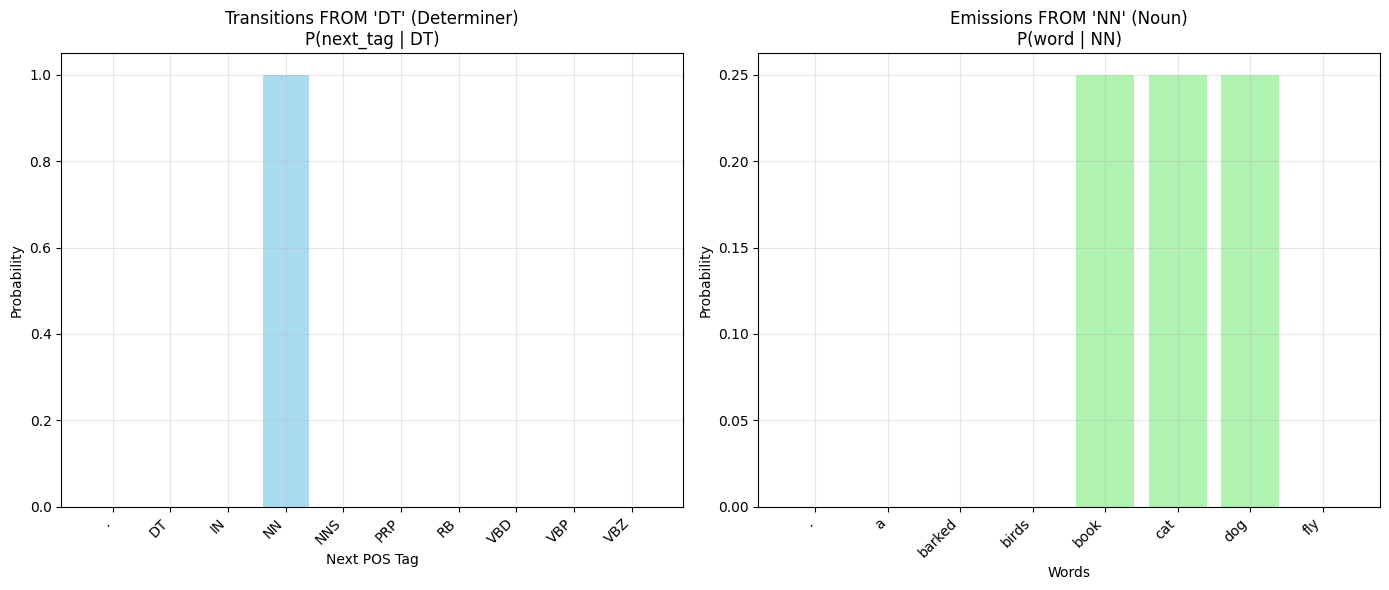


✓ Visualization saved: 'hmm_pos_tagging_complete_demo.png'

DEMO COMPLETE: HMM successfully trained and applied to POS tagging!
Key takeaways:
- A: Captures grammar (DT→NN, NN→VB patterns)
- B: Captures lexicon (nouns emit 'cat', verbs emit 'runs')
- Viterbi: Finds optimal tag sequence efficiently O(T×N²)


In [ ]:
# =============================================================================
# STEP 6: VISUALIZATION - HMM MATRICES
# =============================================================================
"""
Plot key HMM components to understand what the model learned.
Left: Transitions FROM 'DT' state (where does 'the' typically lead?)
Right: Emissions FROM 'NN' state (which words are nouns?)
"""

# Find indices for visualization
dt_idx = state_id['DT']  # Determiner state
nn_idx = state_id['NN']  # Noun state

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# PLOT 1: Transition probabilities FROM DT state
ax1.bar(range(len(states)), A[dt_idx], alpha=0.7, color='skyblue')
ax1.set_title("Transitions FROM 'DT' (Determiner)\nP(next_tag | DT)", fontsize=12)
ax1.set_xlabel("Next POS Tag")
ax1.set_ylabel("Probability")
ax1.set_xticks(range(0, len(states), max(1, len(states)//10)))  # Show subset of labels
ax1.set_xticklabels([states[i] for i in range(0, len(states), max(1, len(states)//10))], 
                    rotation=45, ha='right')
ax1.grid(True, alpha=0.3)

# PLOT 2: Emission probabilities FROM NN state (top words)
top_words = 8
ax2.bar(range(top_words), B[nn_idx, :top_words], alpha=0.7, color='lightgreen')
ax2.set_title("Emissions FROM 'NN' (Noun)\nP(word | NN)", fontsize=12)
ax2.set_xlabel("Words")
ax2.set_ylabel("Probability")
ax2.set_xticks(range(top_words))
ax2.set_xticklabels(words[:top_words], rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hmm_pos_tagging_complete_demo.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved: 'hmm_pos_tagging_complete_demo.png'")
print("\n" + "="*60)
print("DEMO COMPLETE: HMM successfully trained and applied to POS tagging!")
print("Key takeaways:")
print("- A: Captures grammar (DT→NN, NN→VB patterns)")
print("- B: Captures lexicon (nouns emit 'cat', verbs emit 'runs')") 
print("- Viterbi: Finds optimal tag sequence efficiently O(T×N²)")
print("="*60)
